In [1]:
import pandas as pd

import pickle

from tqdm import tqdm

import os
from dotenv import load_dotenv

from IPython.display import display, Markdown

from langchain_openai import ChatOpenAI

import json

import numpy as np

import concurrent.futures
import logging

from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder

import seaborn as sns # Optional: for a visual heatmap
import matplotlib.pyplot as plt # Optional: for plotting

from adr import adr
import utils
from adr_classification import ADRClassifier, ClassificationFramework
from adr_classification import ZimmermannEnum, KruchtenEnum, QualityAttributesEnum

import logging


---

In [2]:

ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

# logging.basicConfig(stream=sys.stdout, level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

print(load_dotenv())

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_MODEL_NAME"] = 'gpt-4o-mini'
print(os.environ["OPENAI_MODEL_NAME"])

True
gpt-4.1-mini


In [3]:
# Datasets with examples manually tagged by humans
# KRUCHTEN_GROUND_TRUTH = './sample/kruchten_gt_processed1.csv'
KRUCHTEN_GROUND_TRUTH = './sample/kruchten_gt_processed1_checked1.csv'

# Datasets of examples for few-shot strategy
KRUCHTEN_FEW_SHOTS = '../sample/krutchen_fewshots_raw.json'

---

### Load the Dataset of ADRs

In [4]:
# Configure LLM via Langchain
llm = ChatOpenAI(
      model=os.environ["OPENAI_MODEL_NAME"], temperature=0.0, 
      # callback_manager=CallbackManager([StreamingStdOutCallbackHandler()])
)
# llm.invoke("Tell me a joke about data scientists")

In [5]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

547 projects/organizations?


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


In [6]:
# Select a sample set of ADRs to classify
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

---

### 1. Krutchen's Taxonomy

In [7]:
# Load ground truth
relative_path = os.path.join('..', KRUCHTEN_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR', 'raw_text'])
print(df_gt.shape)

# Print the categories (4) covered by the ground truth
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

adr_texts = {row['ADR']: row['raw_text'] for _, row in df_gt.iterrows()}
df_gt.head()

(200, 10)
4 ['Existence (ontocrisis)' 'Executive (pericrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']
4 ['Existence (ontocrisis)' 'Property (diacrisis)' 'Executive (pericrisis)'
 'Ban/Non-Existence (anticrisis)']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,human_old,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Existence (ontocrisis),The ADR describes the implementation of a conn...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Existence (ontocrisis),The ADR describes a decision to implement prov...,"0,85",Existence (ontocrisis),Existence (ontocrisis),1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Property (diacrisis),The ADR primarily discusses versioning strateg...,"0,80",Executive (pericrisis),Executive (pericrisis),0.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Existence (ontocrisis),The ADR primarily discusses decisions related ...,"0,85",Executive (pericrisis),Existence (ontocrisis),1.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Executive (pericrisis),The ADR discusses a process and policy change ...,"0,90",Executive (pericrisis),Executive (pericrisis),1.0,# Cutting release branch does not create a set...


In [8]:
labels = sorted([str(member.value) for member in KruchtenEnum])
print(len(labels), labels)

# Encoding target
# le = LabelEncoder()
# encoding = le.fit_transform(labels)


4 ['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Existence (ontocrisis)', 'Property (diacrisis)']


In [9]:
# Get a particular (random) ADR from the ground truth to test classification
adr_example = df_gt['raw_text'].tolist()[8]
# adr_example = list(adr_texts.values())[8]
adr_example

"# Web Application\n\n**Status:** Accepted\n\n## Context\n\nWe need an application platform that meets the following requirements:\n\n- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.\n- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.\n\n### Option 1 - Cache First Web App (PWA)\n\nBy creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.\n\n### Option 2 - Native application\n\nAnother option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed m

#### Zero-shot Strategy

In [10]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.KRUCHTEN, include_examples=False)

{"asctime": "2026-01-07 09:32:54,765", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=False"}


In [11]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one and only one category. 
Use the category definitions, guidelines and rules provided below, which are derived from Kruchten’s ontology of architectural decisions in software-intensive systems.

## Categories:
- **Existence (ontocrisis)**: This decision declares that an *element or artifact will exist* in the design or implementation. Includes structural decisions (e.g., layers, components) and behavioral decisions (e.g., connectors, interactions). Structural decisions lead to the creation of subsystems, layers, partitions, components in some view of the architecture. Behavioural decisions are more related to how the elements interact together to provide functionality or to satisfy some non functional requirement (quality attribute), or connectors.
- **Ban/Non-Existence (anticrisis)**: This decision declares that an *element will not exist* in the de

In [12]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-07 09:32:57,722", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "kruchten",
    "primary_category": "Existence (ontocrisis)",
    "explanation": "The ADR primarily decides on the existence of a specific architectural element: a web application with offline capabilities (a Progressive Web App) as the platform for the system. This is a structural decision about what kind of application will be built and deployed. Although there are references to development feasibility and resource constraints, the core decision is about selecting the type of application to exist in the system, not about process or organizational aspects. Therefore, it fits best under the Existence category. It is not a Property decision because it does not set a general quality or constraint but chooses a concrete element. It is not Ban/Non-Existence because it does not forbid an element but selects one. It is not Executive becau

# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

In [13]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_zero_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/kruchten_gt_processed1_checked1_zero_shot_results.json


In [14]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=4)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=4)

In [15]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Property (diacrisis)', 'Existence (ontocrisis)']

Matthews Coefficient: 0.20333991628181894
Similarities with GT (%): 61.5
Kappa agreement with GT: 0.18241664897005716


{'Ban/Non-Existence (anticrisis)': 0.24863387978142082,
 'Executive (pericrisis)': 0.09170305676855894,
 'Existence (ontocrisis)': 0.27122555569051376,
 'Property (diacrisis)': 0.09197422378441711}

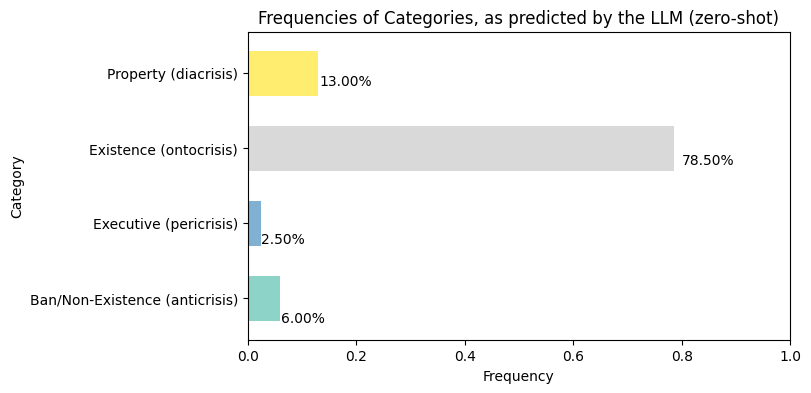

In [16]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (zero-shot)"
my_colors = utils.show_target_frequencies(pd.Series(target_values), title=title) #, encoding=encoding)

In [17]:
my_colors

{'Ban/Non-Existence (anticrisis)': '#8dd3c7',
 'Executive (pericrisis)': '#80b1d3',
 'Existence (ontocrisis)': '#d9d9d9',
 'Property (diacrisis)': '#ffed6f'}

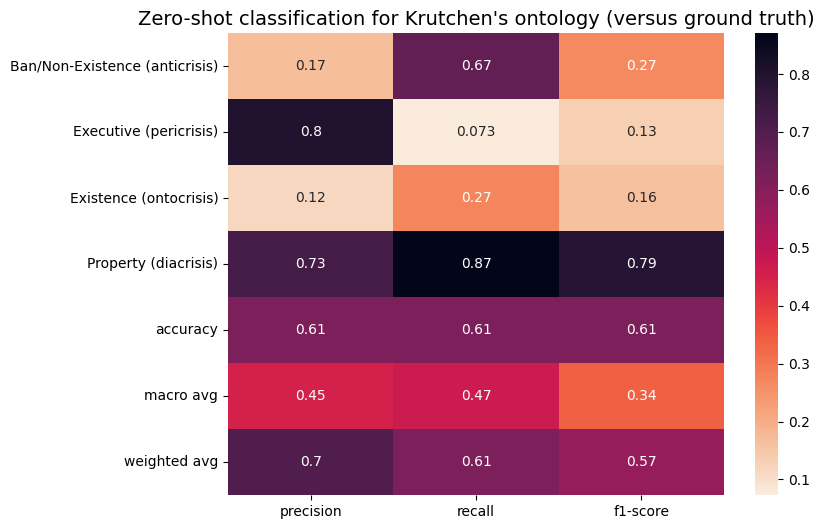

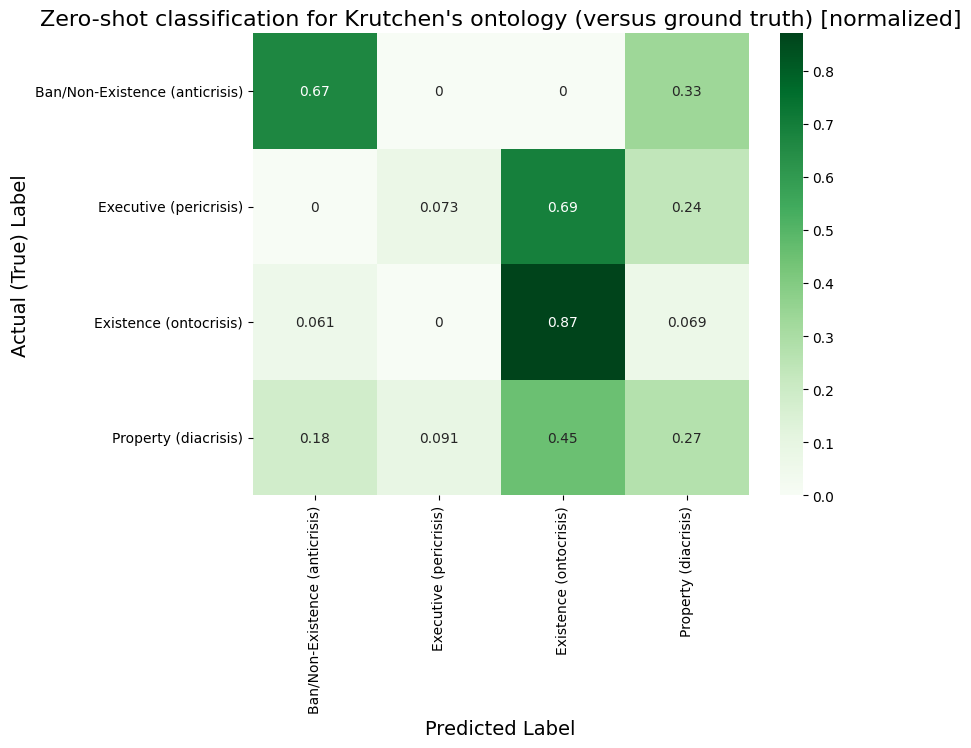

In [18]:
title = "Zero-shot classification for Krutchen's ontology (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

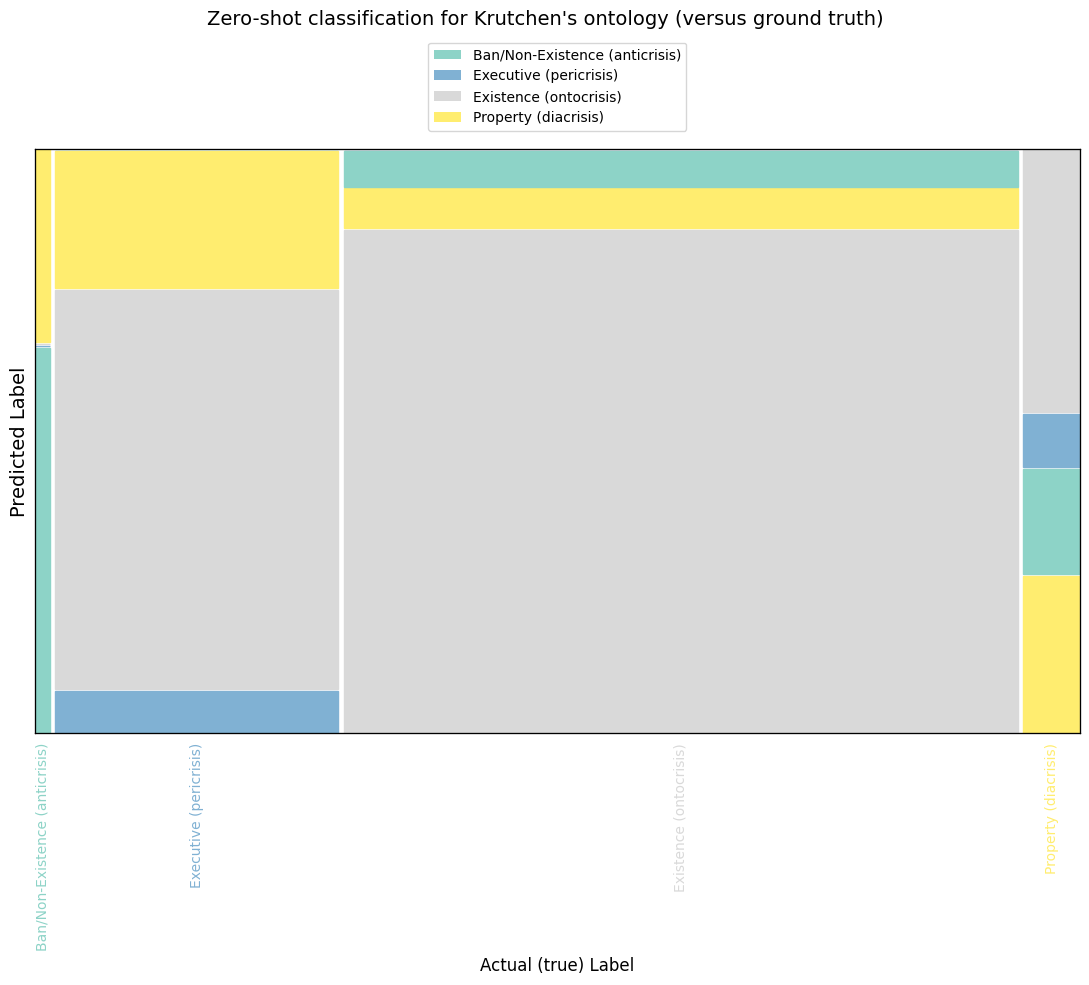

In [19]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [20]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=4)

Differences with GT: 77


[(('Executive (pericrisis)', 'Existence (ontocrisis)'), 38),
 (('Executive (pericrisis)', 'Property (diacrisis)'), 13),
 (('Existence (ontocrisis)', 'Property (diacrisis)'), 9),
 (('Existence (ontocrisis)', 'Ban/Non-Existence (anticrisis)'), 8)]

#### Few-shot Strategy (static)

In [21]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.KRUCHTEN, include_examples=True)

{"asctime": "2026-01-07 09:33:03,356", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=True"}


In [22]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one and only one category. 
Use the category definitions, guidelines, rules and examples provided below, which are derived from Kruchten’s ontology of architectural decisions in software-intensive systems.

## Categories:
- **Existence (ontocrisis)**: This decision declares that an *element or artifact will exist* in the design or implementation. Includes structural decisions (e.g., layers, components) and behavioral decisions (e.g., connectors, interactions). Structural decisions lead to the creation of subsystems, layers, partitions, components in some view of the architecture. Behavioural decisions are more related to how the elements interact together to provide functionality or to satisfy some non functional requirement (quality attribute), or connectors.
Examples:
    + ✅ "We will use PostgreSQL as our primary database"
    + ✅ "Implement an API 

In [23]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-07 09:33:03,397", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "kruchten",
    "primary_category": "Existence (ontocrisis)",
    "explanation": "The ADR primarily decides on the architectural element to be created: a web application with offline capabilities (a Progressive Web App). This is a decision about what software element will exist in the system design. It is not about forbidding elements (Ban), setting general system rules (Property), or development processes (Executive). Although there are considerations about development feasibility, the core decision is about the existence of a PWA as the application platform.",
    "primary_score": 0.9,
    "alternative_categories": [
        "Executive (pericrisis)"
    ],
    "alternative_confidence_scores": [
        0.1
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

In [24]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_static_few_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/kruchten_gt_processed1_checked1_static_few_shot_results.json


In [25]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=4)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=4)

In [26]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Property (diacrisis)', 'Existence (ontocrisis)']

Matthews Coefficient: 0.26976972537544835
Similarities with GT (%): 63.0
Kappa agreement with GT: 0.25086049807653377


{'Ban/Non-Existence (anticrisis)': 0.2913385826771653,
 'Executive (pericrisis)': 0.19933277731442878,
 'Existence (ontocrisis)': 0.3444925670139296,
 'Property (diacrisis)': 0.11347517730496448}

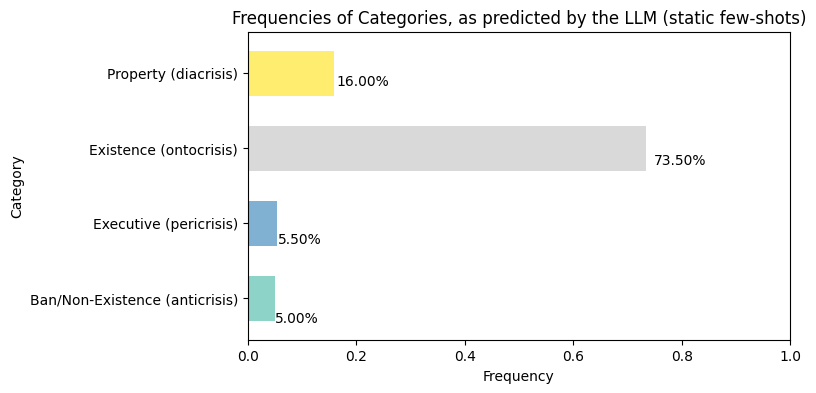

In [27]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (static few-shots)"
my_colors = utils.show_target_frequencies(pd.Series(target_values), title=title) #, encoding=encoding)

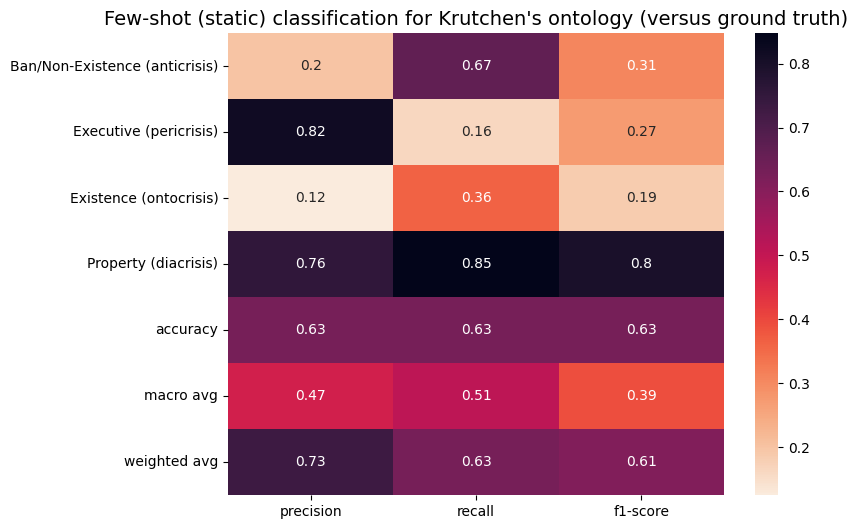

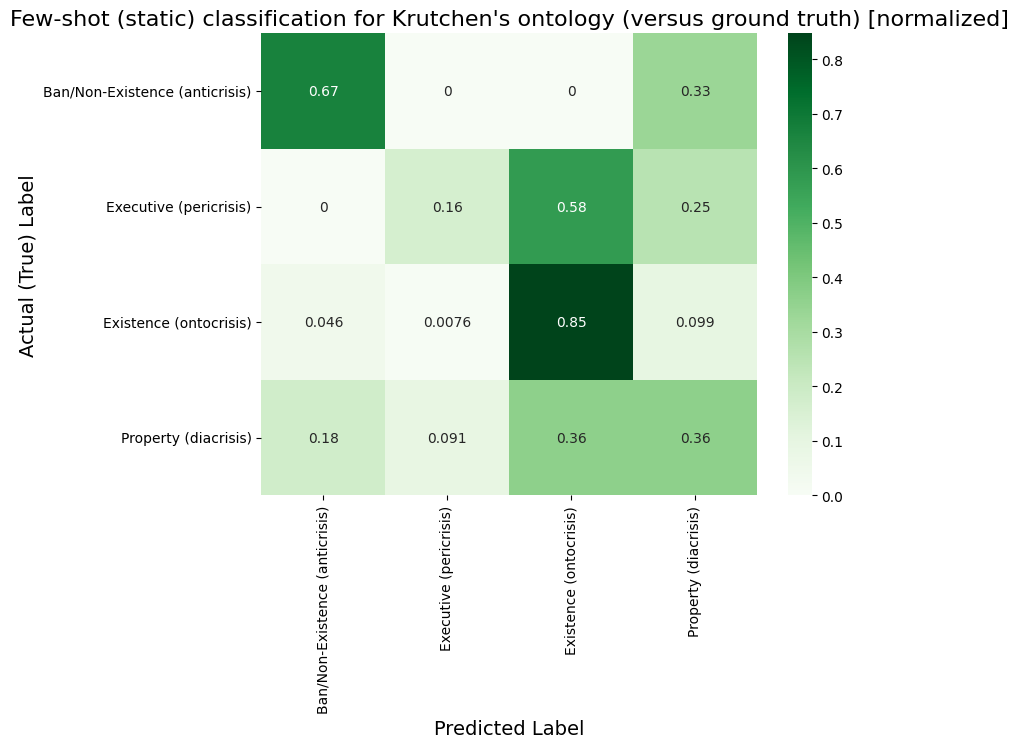

In [28]:
title = "Few-shot (static) classification for Krutchen's ontology (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

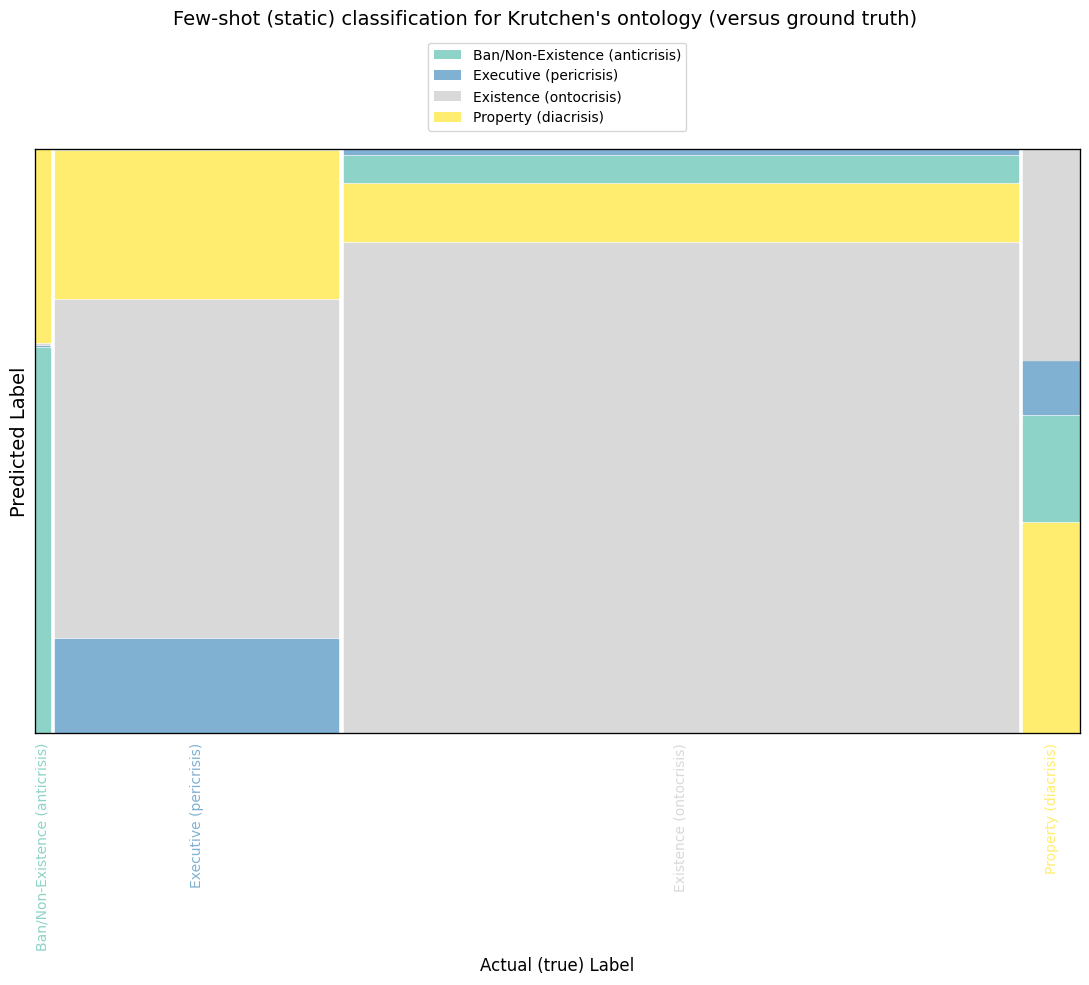

In [29]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [30]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=4)

Differences with GT: 74


[(('Executive (pericrisis)', 'Existence (ontocrisis)'), 32),
 (('Executive (pericrisis)', 'Property (diacrisis)'), 14),
 (('Existence (ontocrisis)', 'Property (diacrisis)'), 13),
 (('Existence (ontocrisis)', 'Ban/Non-Existence (anticrisis)'), 6)]

#### Few-shot Strategy (dynamic)

In [31]:
with open(KRUCHTEN_FEW_SHOTS, mode='r') as file:
        # The 'data' variable will be a Python list of dictionaries
        adr_examples = json.load(file)
# adr_examples

In [32]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.KRUCHTEN, include_examples=True, examples=adr_examples, k=7)

{"asctime": "2026-01-07 09:33:07,377", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=True"}


In [33]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one and only one category. 
Use the category definitions, guidelines and rules provided below, which are derived from Kruchten’s ontology of architectural decisions in software-intensive systems.

## Categories:
- **Existence (ontocrisis)**: This decision declares that an *element or artifact will exist* in the design or implementation. Includes structural decisions (e.g., layers, components) and behavioral decisions (e.g., connectors, interactions). Structural decisions lead to the creation of subsystems, layers, partitions, components in some view of the architecture. Behavioural decisions are more related to how the elements interact together to provide functionality or to satisfy some non functional requirement (quality attribute), or connectors.
- **Ban/Non-Existence (anticrisis)**: This decision declares that an *element will not exist* in the design or 

In [34]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-07 09:33:21,655", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "kruchten",
    "primary_category": "Existence (ontocrisis)",
    "explanation": "The ADR's core decision is about selecting the type of application platform to build (a web app with offline capabilities) which is a decision about what software element will exist in the system. It is not about forbidding elements, setting system-wide properties, or dictating development processes. Although it discusses some issues with the chosen approach, the primary focus is on the existence of a web app as the architectural element to be built.",
    "primary_score": 0.85,
    "alternative_categories": [
        "Property (diacrisis)"
    ],
    "alternative_confidence_scores": [
        0.15
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)

In [35]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_dynamic_few_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/kruchten_gt_processed1_checked1_dynamic_few_shot_results.json


In [36]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=4)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=4)

{"asctime": "2026-01-07 09:33:27,227", "levelname": "WARNING", "name": "adr_classification", "message": "Dropping 4 as they are not part of the LLM results. ['0016-not-supporting-type-definitions.md', 'zindex-values.md', 'adr-067-mempool-refactor.md', '0002-use-bullet-to-catch-nplus1-queries.md']"}


In [37]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Ban/Non-Existence (anticrisis)', 'Executive (pericrisis)', 'Property (diacrisis)', 'Existence (ontocrisis)']

Matthews Coefficient: 0.40461784599152417
Similarities with GT (%): 66.3265306122449
Kappa agreement with GT: 0.38781884435190006


{'Ban/Non-Existence (anticrisis)': 0.48825065274151436,
 'Executive (pericrisis)': 0.3799382716049383,
 'Existence (ontocrisis)': 0.43023255813953487,
 'Property (diacrisis)': 0.2904782799473453}

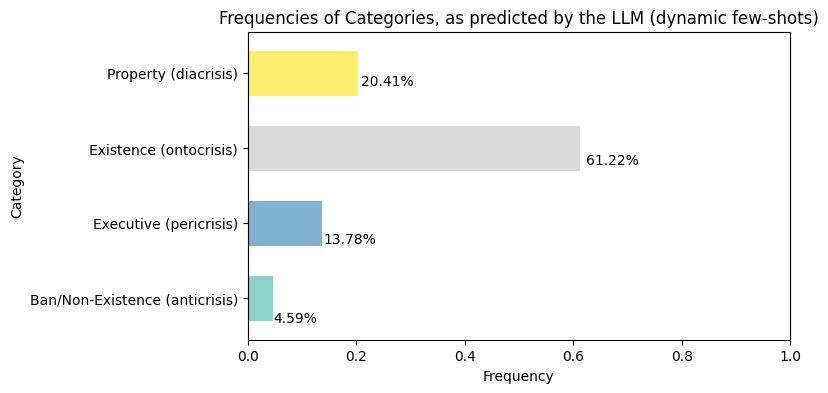

In [38]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (dynamic few-shots)"
my_colors = utils.show_target_frequencies(pd.Series(target_values), title=title) #, encoding=encoding)

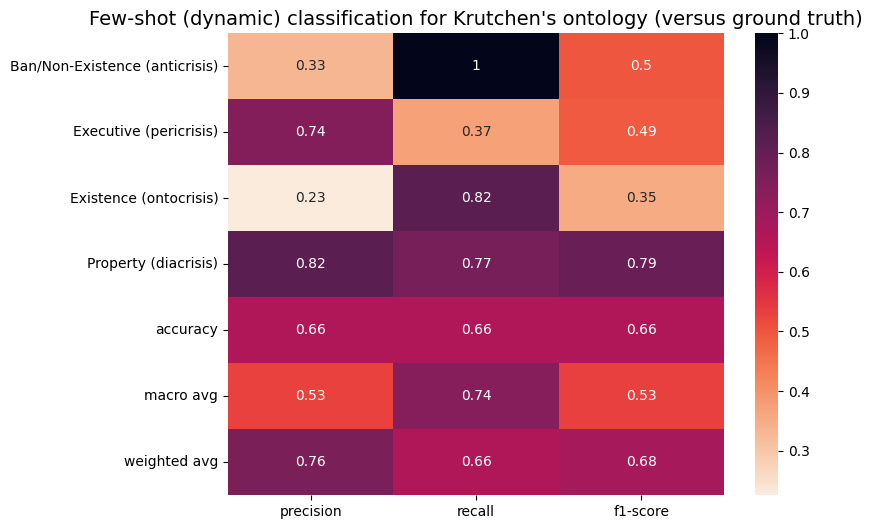

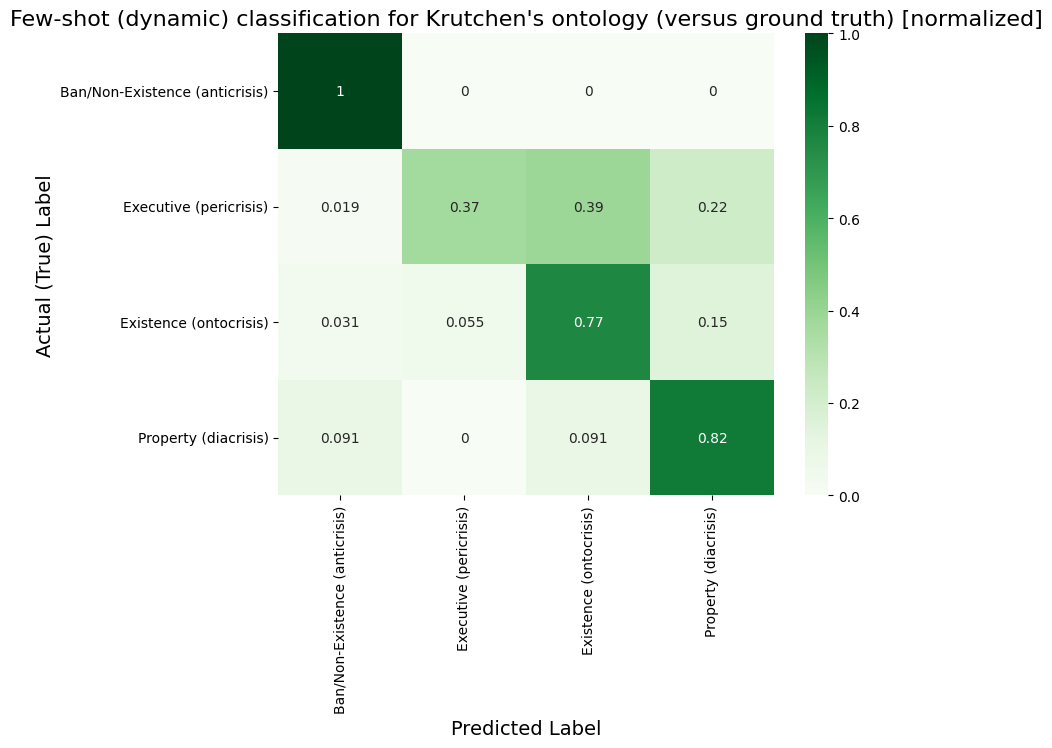

In [39]:
title = "Few-shot (dynamic) classification for Krutchen's ontology (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

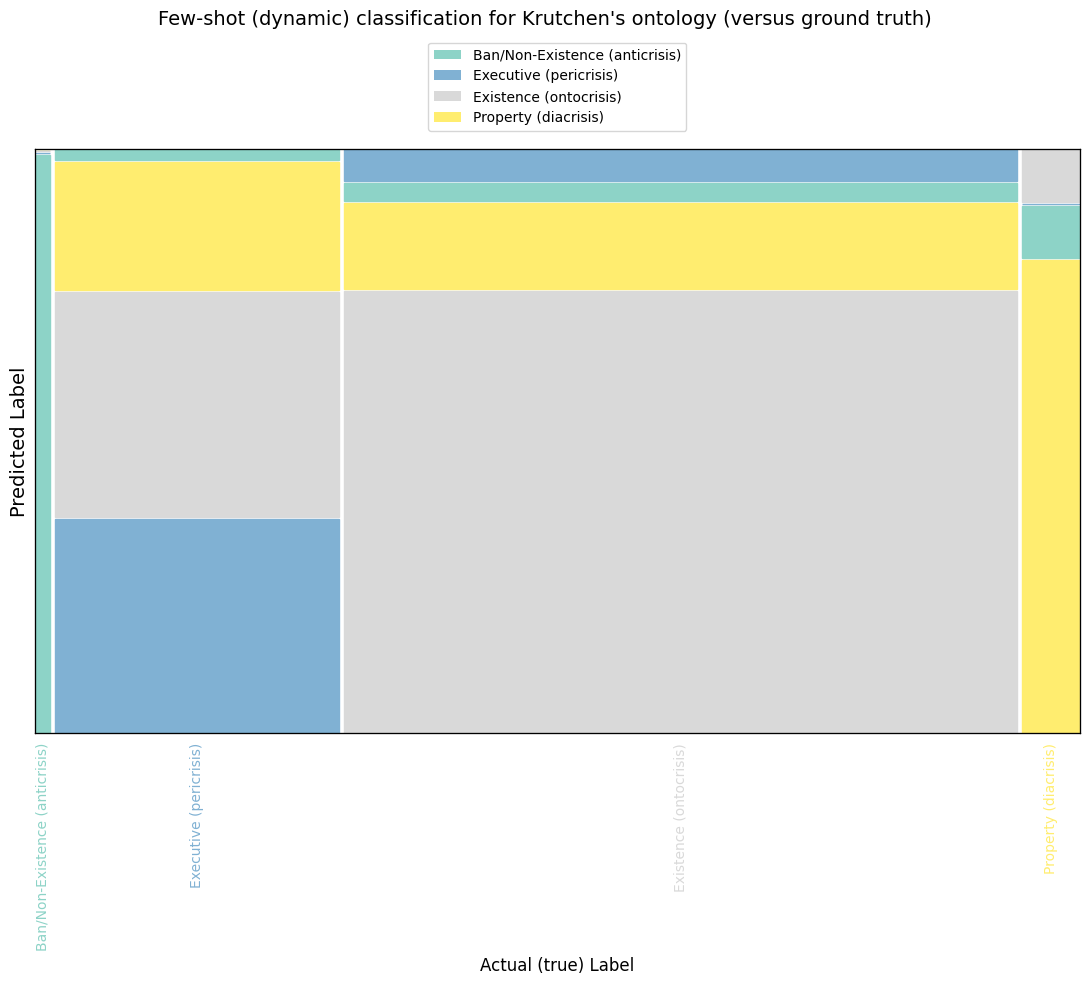

In [40]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [41]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=4)

Differences with GT: 66


[(('Executive (pericrisis)', 'Existence (ontocrisis)'), 21),
 (('Existence (ontocrisis)', 'Property (diacrisis)'), 19),
 (('Executive (pericrisis)', 'Property (diacrisis)'), 12),
 (('Existence (ontocrisis)', 'Executive (pericrisis)'), 7)]

---

## Applying the Classifier to the Dataset of ADRs

In [42]:
ALL_PROJECTS_RESULTS = './results/all_projects-krutchen_classification_results.json'

In [43]:
# TODO: Run the dynamic few-shots strategy on the FULL set of ADRs (there's no ground truth for all of them)

best_classifier = ADRClassifier(llm) # Dynamic few-shots
best_classifier.set_framework(ClassificationFramework.KRUCHTEN, include_examples=True, examples=adr_examples, k=7)

{"asctime": "2026-01-07 09:33:27,773", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: kruchten, include_examples=True"}


In [47]:
# logging.disable(logging.INFO) 
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

relative_path = os.path.join('..', ALL_PROJECTS_RESULTS)

# Now use batch mode to check all the ADRs for all the projects
all_results = []
if not os.path.isfile(relative_path):
    print(f"Classifying results for all (valid) {len(valid_projects)} projects")
    for org, project in tqdm(valid_projects, desc="Processing org/projects"):
        adrs_to_check = utils.get_documents_by_key((org, project), dict_adrs, field='raw')
        # print("==", org, project, ":", len(adrs_to_check), "ADRs to check")
        results = best_classifier.classify_batch(adrs_to_check, parallel=True, project=project, organization=org, as_dict=True)
        all_results.extend(results)

# logging.basicConfig(level=logging.INFO)
# logging.disable(logging.NOTSET)
    print()
    print("Saving JSON results to", relative_path)
    ADRClassifier.save_results(all_results, relative_path)

print("End.")

Classifying results for all (valid) 312 projects


Processing org/projects:   1%|          | 2/312 [00:12<32:11,  6.23s/it]WARNING:root:A parsing error occurred (using f-string formatting instead): {'adr': '2021-11-05-adjust-ADR-approval-rules.md'}
ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': '2021-11-05-adjust-ADR-approval-rules.md'}
Processing org/projects:   7%|▋         | 22/312 [03:40<34:44,  7.19s/it]  WARNING:root:A parsing error occurred (using f-string formatting instead): {'adr': '0012-we-will-use-the-full-profile.md'}
ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': '0012-we-will-use-the-full-profile.md'}
Processing org/projects:  11%|█         | 34/312 [05:25<39:13,  8.47s/it]WARNING:root:A parsing error occurred (using f-string formatting instead): {'adr': 'zindex-values.md'}
ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': 'zindex-values.md'}
Processing org/projects:  11%|█         | 35/312 [05:33<37:51,  8.20s/it]WARNING:root:A 


Saving JSON results to .././results/all_projects-krutchen_classification_results.json
End.


In [48]:
print(len(all_results),"ADRs processed.")

4213 ADRs processed.


---